<a href="https://colab.research.google.com/github/kendala545-dot/mis433/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import seaborn as sns

In [63]:
import os
output_dir = '/content/drive/My Drive/Colab Notebooks/output/'
os.makedirs(output_dir, exist_ok=True)
print(f'Submission files will be saved to: {output_dir}')

Submission files will be saved to: /content/drive/My Drive/Colab Notebooks/output/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read the data files

churn_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/churn_train.csv', header=0)

accounts = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/accounts.csv', header=0)

demographics = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/demographics.csv', header=0)

services = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/services.csv', header=0)

In [ ]:
# Display dataframes

services.head()

,CustomerNo,TypeOfService,SeviceDetails
0,1201,DeviceProtection,Yes
1,1201,HasPhoneService,1
2,1201,InternetServiceCategory,Fiber optic
3,1201,MultipleLines,No
4,1201,OnlineBackup,No


In [ ]:
churn_train.head()

,CustomerNo,Churn
0,1201,0
1,1202,0
2,1205,1
3,1206,0
4,1207,0


In [ ]:
accounts.head()

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic)
3,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic)
4,1205,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check


In [ ]:
demographics.head()

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
0,1201,India,Maharashtra,0,2,2,Masters,Male
1,1202,India,Maharashtra,0,2,2,ProfessionalQalification,Male
2,1203,India,Maharashtra,0,2,2,ProfessionalQalification,Male
3,1204,India,Maharashtra,0,2,1,ProfessionalQalification,Male
4,1205,India,Maharashtra,0,2,2,ProfessionalQalification,Female


In [ ]:
# Describe dataframes using info()

churn_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  4238 non-null   int64
 1   Churn       4238 non-null   int64
dtypes: int64(2)
memory usage: 66.3 KB


In [ ]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerNo         5298 non-null   int64  
 1   BaseCharges        5298 non-null   float64
 2   DOC                5298 non-null   object 
 3   TotalCharges       5288 non-null   float64
 4   DOE                5298 non-null   object 
 5   ElectronicBilling  5298 non-null   object 
 6   ContractType       5293 non-null   object 
 7   PaymentMethod      5298 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 331.3+ KB


In [ ]:
demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     5298 non-null   int64 
 1   Country        5298 non-null   object
 2   State          5298 non-null   object
 3   Retired        5298 non-null   int64 
 4   HasPartner     5298 non-null   int64 
 5   HasDependents  5298 non-null   int64 
 6   Education      5288 non-null   object
 7   Gender         5294 non-null   object
dtypes: int64(4), object(4)
memory usage: 331.3+ KB


In [ ]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47682 entries, 0 to 47681
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     47682 non-null  int64 
 1   TypeOfService  47682 non-null  object
 2   SeviceDetails  47682 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [ ]:
# Describe dataframes using describe()

In [ ]:
display(churn_train.describe(include='all'))

,CustomerNo,Churn
count,4238.000000,4238.000000
mean,3841.604059,0.247522
std,1535.584457,0.431624
min,1201.000000,0.000000
25%,2506.250000,0.000000
50%,3849.500000,0.000000
75%,5168.750000,0.000000
max,6498.000000,1.000000


In [ ]:
display(accounts.describe(include='all'))

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
count,5298.000000,5298.000000,5298,5288.000000,5298,5298,5293,5298
unique,NaN,NaN,1,NaN,73,2,3,4
top,NaN,NaN,5-1-2012,NaN,6-Dec-11,Yes,Month-to-month,Electronic check
freq,NaN,NaN,5298,NaN,423,3120,2779,1586
mean,3849.500000,325.467205,NaN,11928.354056,NaN,NaN,NaN,NaN
std,1529.545194,151.352954,NaN,11486.453199,NaN,NaN,NaN,NaN
min,1201.000000,91.250000,NaN,94.250000,NaN,NaN,NaN,NaN
25%,2525.250000,178.250000,NaN,2314.937500,NaN,NaN,NaN,NaN
50%,3849.500000,352.500000,NaN,7377.500000,NaN,NaN,NaN,NaN
75%,5173.750000,451.250000,NaN,19992.812500,NaN,NaN,NaN,NaN


In [ ]:
display(demographics.describe(include='all'))

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
count,5298.000000,5298,5298,5298.000000,5298.000000,5298.000000,5288,5294
unique,NaN,2,2,NaN,NaN,NaN,5,2
top,NaN,India,Maharashtra,NaN,NaN,NaN,Highschool or below,Male
freq,NaN,5293,5290,NaN,NaN,NaN,1426,2656
mean,3849.500000,NaN,NaN,0.158362,1.502454,1.690827,NaN,NaN
std,1529.545194,NaN,NaN,0.365114,0.500041,0.462196,NaN,NaN
min,1201.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
25%,2525.250000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
50%,3849.500000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN
75%,5173.750000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN


In [ ]:
display(services.describe(include='all'))

,CustomerNo,TypeOfService,SeviceDetails
count,47682.000000,47682,47682
unique,NaN,9,8
top,NaN,DeviceProtection,No
freq,NaN,5298,17410
mean,3849.500000,NaN,NaN
std,1529.416874,NaN,NaN
min,1201.000000,NaN,NaN
25%,2525.000000,NaN,NaN
50%,3849.500000,NaN,NaN
75%,5174.000000,NaN,NaN


In [ ]:
# Pivot services from long to wide format
services2 = services.pivot_table(index='CustomerNo', columns='TypeOfService', values='SeviceDetails', aggfunc='first').reset_index()

services2.head()

TypeOfService,CustomerNo,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1203,No,1,Fiber optic,No,No,No,Yes,No,No
3,1204,No,1,DSL,Yes,Yes,Yes,No,No,Yes
4,1205,No,1,Fiber optic,Yes,No,No,No,No,No


In [ ]:
# Merge all into one dataset
df = churn_train.merge(demographics, on='CustomerNo')
df = df.merge(services2, on='CustomerNo')
df = df.merge(accounts, on='CustomerNo')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerNo               4238 non-null   int64  
 1   Churn                    4238 non-null   int64  
 2   Country                  4238 non-null   object 
 3   State                    4238 non-null   object 
 4   Retired                  4238 non-null   int64  
 5   HasPartner               4238 non-null   int64  
 6   HasDependents            4238 non-null   int64  
 7   Education                4229 non-null   object 
 8   Gender                   4236 non-null   object 
 9   DeviceProtection         4238 non-null   object 
 10  HasPhoneService          4238 non-null   object 
 11  InternetServiceCategory  4238 non-null   object 
 12  MultipleLines            4238 non-null   object 
 13  OnlineBackup             4238 non-null   object 
 14  OnlineSecurity          

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['CustomerNo'])
df

,Churn,Country,State,Retired,HasPartner,HasDependents,Education,Gender,DeviceProtection,HasPhoneService,...,StreamingMovies,StreamingTelevision,TechnicalSupport,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,0,India,Maharashtra,0,2,2,Masters,Male,Yes,1,...,Yes,Yes,No,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,0,India,Maharashtra,0,2,2,ProfessionalQalification,Male,No internet service,1,...,No internet service,No internet service,No internet service,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1,India,Maharashtra,0,2,2,ProfessionalQalification,Female,No,1,...,No,No,No,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check
3,0,India,Maharashtra,0,2,2,Highschool or below,Male,No internet service,1,...,No internet service,No internet service,No internet service,99.50,5-1-2012,6775.50,7-Mar-06,Yes,Two year,Credit card (automatic)
4,0,India,Maharashtra,0,2,2,Graduation,Male,No internet service,1,...,No internet service,No internet service,No internet service,91.25,5-1-2012,2673.50,17-Sep-09,No,One year,Credit card (automatic)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,0,India,Maharashtra,1,2,2,Masters,Male,No internet service,1,...,No internet service,No internet service,No internet service,100.00,5-1-2012,6980.00,5-Jun-06,Yes,Two year,Credit card (automatic)
4234,0,India,Maharashtra,0,2,1,Masters,Female,Yes,0,...,Yes,No,No,227.75,5-1-2012,10541.75,26-Jan-08,No,Month-to-month,Credit card (automatic)
4235,0,India,Maharashtra,0,2,2,ProfessionalQalification,Male,No internet service,1,...,No internet service,No internet service,No internet service,99.50,5-1-2012,5113.00,27-Dec-07,Yes,Two year,Credit card (automatic)
4236,0,India,Maharashtra,1,1,2,Highschool or below,Male,Yes,1,...,No,Yes,No,426.00,5-1-2012,14372.25,21-Mar-09,Yes,Month-to-month,Credit card (automatic)


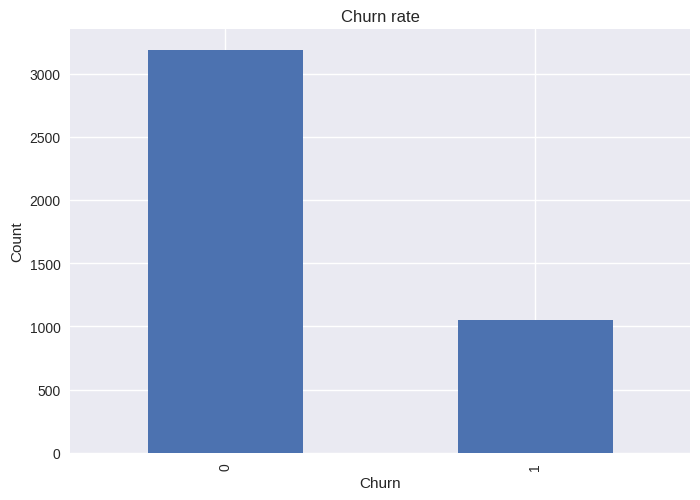

In [ ]:
# Churn rate
fig, ax = plt.subplots()
df['Churn'].value_counts().plot(kind='bar', ax=ax)
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
ax.set_title("Churn rate")
plt.show()

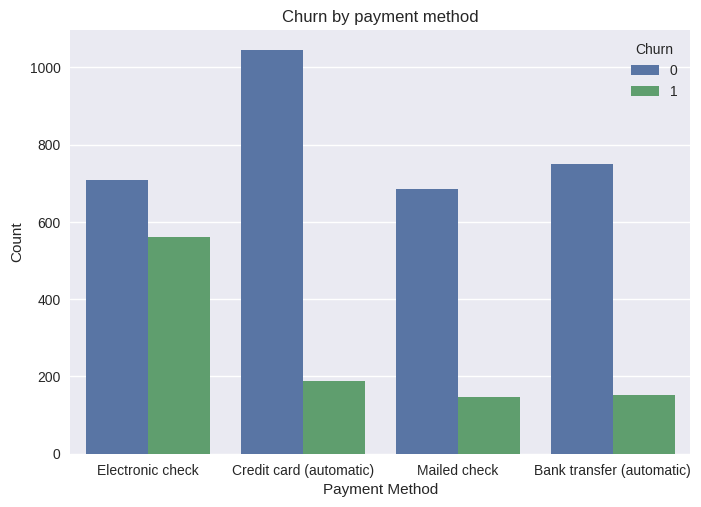

In [ ]:
# Churn by payment method
fig, ax = plt.subplots()
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=ax)
ax.set_xlabel("Payment Method")
ax.set_ylabel("Count")
ax.set_title("Churn by payment method")
plt.show()

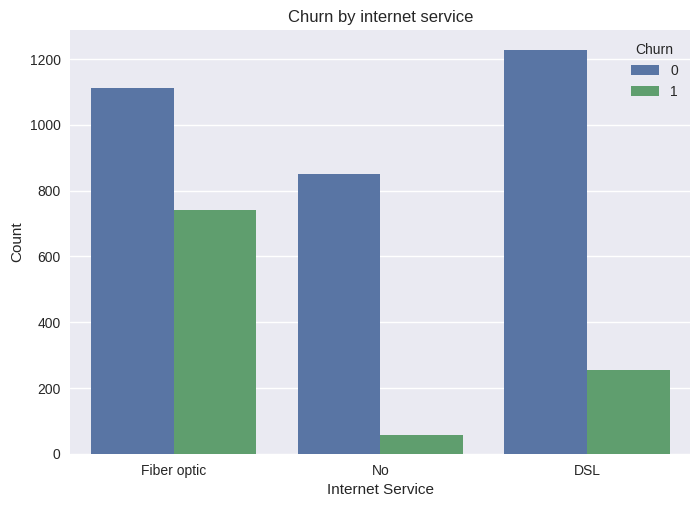

In [ ]:
# Churn by internet service
fig, ax = plt.subplots()
sns.countplot(data=df, x='InternetServiceCategory', hue='Churn', ax=ax)
ax.set_xlabel("Internet Service")
ax.set_ylabel("Count")
ax.set_title("Churn by internet service")
plt.show()

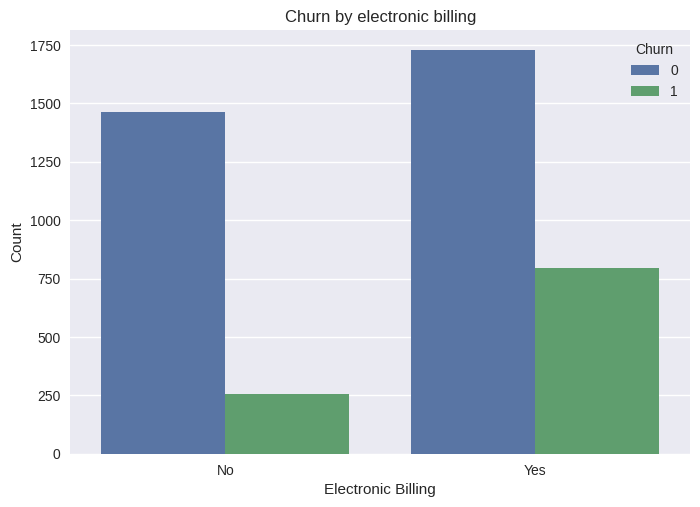

In [ ]:
# Churn by electronic billing
fig, ax = plt.subplots()
sns.countplot(data=df, x='ElectronicBilling', hue='Churn', ax=ax)
ax.set_xlabel("Electronic Billing")
ax.set_ylabel("Count")
ax.set_title("Churn by electronic billing")
plt.show()

In [ ]:
df

,Churn,Country,State,Retired,HasPartner,HasDependents,Education,Gender,DeviceProtection,HasPhoneService,...,StreamingMovies,StreamingTelevision,TechnicalSupport,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,0,India,Maharashtra,0,2,2,Masters,Male,Yes,1,...,Yes,Yes,No,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,0,India,Maharashtra,0,2,2,ProfessionalQalification,Male,No internet service,1,...,No internet service,No internet service,No internet service,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1,India,Maharashtra,0,2,2,ProfessionalQalification,Female,No,1,...,No,No,No,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check
3,0,India,Maharashtra,0,2,2,Highschool or below,Male,No internet service,1,...,No internet service,No internet service,No internet service,99.50,5-1-2012,6775.50,7-Mar-06,Yes,Two year,Credit card (automatic)
4,0,India,Maharashtra,0,2,2,Graduation,Male,No internet service,1,...,No internet service,No internet service,No internet service,91.25,5-1-2012,2673.50,17-Sep-09,No,One year,Credit card (automatic)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,0,India,Maharashtra,1,2,2,Masters,Male,No internet service,1,...,No internet service,No internet service,No internet service,100.00,5-1-2012,6980.00,5-Jun-06,Yes,Two year,Credit card (automatic)
4234,0,India,Maharashtra,0,2,1,Masters,Female,Yes,0,...,Yes,No,No,227.75,5-1-2012,10541.75,26-Jan-08,No,Month-to-month,Credit card (automatic)
4235,0,India,Maharashtra,0,2,2,ProfessionalQalification,Male,No internet service,1,...,No internet service,No internet service,No internet service,99.50,5-1-2012,5113.00,27-Dec-07,Yes,Two year,Credit card (automatic)
4236,0,India,Maharashtra,1,1,2,Highschool or below,Male,Yes,1,...,No,Yes,No,426.00,5-1-2012,14372.25,21-Mar-09,Yes,Month-to-month,Credit card (automatic)


In [ ]:
# Keep all features as independent variables and Churn as dependent variable
df_X = df.drop(columns=['Churn'])
df_y = df['Churn']

In [ ]:
# Use get_dummies() to convert categorical variables to dummy variables
df_X_onehot = pd.get_dummies(df_X)
df_X_onehot.head()

,Retired,HasPartner,HasDependents,BaseCharges,TotalCharges,Country_?,Country_India,State_?,State_Maharashtra,Education_Graduation,...,DOE_9-Jun-11,ElectronicBilling_No,ElectronicBilling_Yes,ContractType_Month-to-month,ContractType_One year,ContractType_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,2,2,478.50,5920.00,False,True,False,True,False,...,False,True,False,False,True,False,False,False,True,False
1,0,2,2,103.25,103.25,False,True,False,True,False,...,False,True,False,True,False,False,False,False,True,False
2,0,2,2,372.50,372.50,False,True,False,True,False,...,False,False,True,True,False,False,False,False,True,False
3,0,2,2,99.50,6775.50,False,True,False,True,False,...,False,False,True,False,False,True,False,True,False,False
4,0,2,2,91.25,2673.50,False,True,False,True,True,...,False,True,False,False,True,False,False,True,False,False


In [ ]:
# Standardize numeric variables
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()
df_X_scaled = pd.DataFrame(min_max_scaler.fit_transform(df_X_onehot), columns=df_X_onehot.columns)

df_X_scaled.head()

,Retired,HasPartner,HasDependents,BaseCharges,TotalCharges,Country_?,Country_India,State_?,State_Maharashtra,Education_Graduation,...,DOE_9-Jun-11,ElectronicBilling_No,ElectronicBilling_Yes,ContractType_Month-to-month,ContractType_One year,ContractType_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,1.0,0.770647,0.134643,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.023881,0.000208,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.559701,0.006431,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,1.0,0.016418,0.154416,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.000000,0.059611,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [58]:
# Drop rows with missing values
df_X_scaled = df_X_scaled.dropna()
df_y = df_y[df_X_scaled.index]

In [59]:
# Train a logistic regression model
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(df_X_scaled, df_y)

LogisticRegression(max_iter=1000)

In [60]:
# Train a decision tree model
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree_clf.fit(df_X_scaled, df_y)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [61]:
# Train a random forest model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df_X_scaled, df_y)

RandomForestClassifier(random_state=42)

In [62]:
# Evaluate model performance
from sklearn.metrics import accuracy_score
lr_score = lr.score(df_X_scaled, df_y)
tree_score = tree_clf.score(df_X_scaled, df_y)
rf_score = rf.score(df_X_scaled, df_y)

print('Logistic Regression accuracy:', lr_score)
print('Decision Tree accuracy:', tree_score)
print('Random Forest accuracy:', rf_score)

Logistic Regression accuracy: 0.8335697399527187
Decision Tree accuracy: 0.8002364066193853
Random Forest accuracy: 0.9988179669030733


In [64]:
# Read test data
churn_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/churn_test.csv', header=0)

# Save customer ID for submission
test_id = churn_test['CustomerNo']

# Merge test data with other files
test_df = churn_test.merge(demographics, on='CustomerNo')
test_df = test_df.merge(services2, on='CustomerNo')
test_df = test_df.merge(accounts, on='CustomerNo')

# Drop CustomerNo
test_df = test_df.drop(columns=['CustomerNo'])

# Encode and scale
test_onehot = pd.get_dummies(test_df)
test_onehot = test_onehot.reindex(columns=df_X_onehot.columns, fill_value=0)
test_scaled = pd.DataFrame(min_max_scaler.transform(test_onehot), columns=test_onehot.columns)

# Make predictions using random forest
y_hat = rf.predict(test_scaled).astype(int)

# Create and save submission file
submission = pd.DataFrame({
    'CustomerNo': test_id,
    'Churn': y_hat,
})
submission.to_csv(f'{output_dir}/churn_submission.csv', index=False)
print("Saved!")

Saved!
